In [76]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time

# Use high precision for stability (VERY important for spectral methods)
torch.set_default_dtype(torch.float64)

In [77]:
def chebyshev_cgl(N):
    """
    Generate Chebyshev-Gauss-Lobatto points in [-1,1]
    
    N = number of intervals
    returns N+1 points
    """
    j = torch.arange(0, N+1)
    x = torch.cos(torch.pi * j / N)
    return x

In [78]:
def chebyshev_diff_matrix(N):
    """
    Build differentiation matrix D such that:
    u_x ≈ D u
    """
    x = chebyshev_cgl(N)
    
    c = torch.ones(N+1)
    c[0] = 2.0
    c[-1] = 2.0
    
    X = x.unsqueeze(0)
    dX = X.T - X
    
    C = c.unsqueeze(0)
    C_ratio = C.T / C
    
    i = torch.arange(N+1)
    sign = (-1.0) ** (i.unsqueeze(0) + i.unsqueeze(1))
    
    # avoid division by zero
    dX = dX + torch.eye(N+1)
    
    D = C_ratio * sign / dX
    
    # fix diagonal entries
    D = D - torch.diag(torch.sum(D, dim=1))
    
    return x, D

In [79]:
def build_A(D, bc_weight=1.0):
    """
    Build full operator A such that:
    r = A u - f
    """
    
    # second derivative
    D2 = D @ D
    
    # PDE part: -u''
    A_pde = -D2
    
    # Boundary conditions
    Np1 = D.shape[0]
    A_bc = torch.zeros(2, Np1)
    
    A_bc[0, 0] = bc_weight       # u(-1)
    A_bc[1, -1] = bc_weight      # u(1)
    
    # Combine
    A = torch.cat([A_pde, A_bc], dim=0)
    
    return A

In [80]:
def chebyshev_basis(x, K):
    """
    Build basis matrix Phi
    
    Phi[i,k] = T_k(x_i)
    """
    
    theta = torch.arccos(x)
    k = torch.arange(0, K)
    
    Phi = torch.cos(theta.unsqueeze(1) * k.unsqueeze(0))
    
    return Phi

In [81]:
import torch.nn as nn

class CoeffNet(nn.Module):
    def __init__(self, K):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(1, 16),
            nn.Tanh(),
            nn.Linear(16, 16),
            nn.Tanh(),
            nn.Linear(16, K)
        )
    
    def forward(self):
        # dummy input (we just want coefficients)
        x = torch.ones(1, 1)
        return self.net(x).view(-1)

In [82]:
def build_B(model):
    """
    Build Jacobian:
    B = dc/dθ
    
    Shape:
    (K, P)
    """
    
    c = model()

    if c.dim() == 0:
        c = c.unsqueeze(0)

    K = c.shape[0]
    
    params = list(model.parameters())
    P = sum(p.numel() for p in params)
    
    B = torch.zeros(K, P)
    
    for k in range(K):
        model.zero_grad()
        c[k].backward(retain_graph=True)
        
        grads = []
        for p in params:
            grads.append(p.grad.view(-1))
        
        B[k] = torch.cat(grads)
    
    return B

In [83]:
def compute_residual(model, A, Phi, f):
    """
    Compute:
    r = A u - f
    """
    
    c = model()
    u = Phi @ c
    
    r = A @ u - f
    
    return r, u, c

In [84]:
# Problem setup

N = 20
K = 20

# Grid + differentiation
x, D = chebyshev_diff_matrix(N)

# Build operator A
A = build_A(D, bc_weight=10.0)

# Basis
Phi = chebyshev_basis(x, K)

# RHS f (example)
f = (torch.pi**2) * torch.sin(torch.pi * x)

# Extend f to match A (important!)
f = torch.cat([f, torch.zeros(2)])

model_smw = CoeffNet(K)

# Method 1: Direct Gauss–Newton using SMW Identity

We solve:

    (J^T J + μI) Δθ = -J^T r

Using structure:

    J = A Φ B

So:

    J^T J = B^T G B
    G = Φ^T A^T A Φ

Instead of solving:

    (B^T G B + μI)

we apply SMW:

    (μI + B^T G B)^{-1}
    = (1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B]

Final update:

    Δθ = -(1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B] B^T Φ^T A^T r

Goal of this section:
- Implement this formula step-by-step
- Keep everything explicit and understandable

# Method 1 with HODLR

We compute:

    G = Φ^T A^T A Φ

But we DO NOT use dense multiplication.

Instead:
- Use HODLR for A v
- Compute A Φ column-by-column

Pipeline:

1. For each basis column Φ_k:
       compute A Φ_k using HODLR

2. Stack results → AΦ

3. Compute:
       G = (AΦ)^T (AΦ)

This avoids O(N^2 K) cost and uses fast matvec.

In [85]:
def aca_pivoted(get_row, get_col, M, N, max_rank):
    U_list, V_list = [], []
    i = 0

    for k in range(max_rank):
        row = get_row(i)
        if U_list:
            row -= sum(u[i] * v for u, v in zip(U_list, V_list))

        j = np.argmax(np.abs(row))
        if abs(row[j]) < 1e-12:
            break

        col = get_col(j)
        if U_list:
            col -= sum(v[j] * u for u, v in zip(U_list, V_list))

        u = col / row[j]
        v = row

        U_list.append(u)
        V_list.append(v)

        i = np.argmax(np.abs(col))

    if len(U_list) == 0:
        return None, None

    return np.column_stack(U_list), np.column_stack(V_list)


def aca_fast(get_row, get_col, M, N, max_rank):
    U_list, V_list = [], []
    i = 0

    for k in range(max_rank):
        row = get_row(i)
        if U_list:
            row -= sum(u[i] * v for u, v in zip(U_list, V_list))

        j = k % N

        if abs(row[j]) < 1e-12:
            continue

        col = get_col(j)
        if U_list:
            col -= sum(v[j] * u for u, v in zip(U_list, V_list))

        u = col / row[j]
        v = row

        U_list.append(u)
        V_list.append(v)

        i = (i + 1) % M

    if len(U_list) == 0:
        return None, None

    return np.column_stack(U_list), np.column_stack(V_list)


def aca_adaptive(get_row, get_col, M, N, tol, max_rank):
    U_list, V_list = [], []
    i = 0
    norm_est = 0.0

    for k in range(max_rank):
        row = get_row(i)
        if U_list:
            row -= sum(u[i] * v for u, v in zip(U_list, V_list))

        j = np.argmax(np.abs(row))
        pivot = row[j]

        if abs(pivot) < 1e-12:
            break

        col = get_col(j)
        if U_list:
            col -= sum(v[j] * u for u, v in zip(U_list, V_list))

        u = col / pivot
        v = row

        U_list.append(u)
        V_list.append(v)

        contrib = np.linalg.norm(u) * np.linalg.norm(v)
        norm_est += contrib

        if contrib < tol * norm_est:
            break

        i = np.argmax(np.abs(col))

    if len(U_list) == 0:
        return None, None

    return np.column_stack(U_list), np.column_stack(V_list)


class Node:
    def __init__(self, r0, r1):
        self.r0, self.r1 = r0, r1
        self.left = None
        self.right = None
        self.U12 = self.V12 = None
        self.U21 = self.V21 = None
        self.dense = None


class RecursiveHODLR:
    def __init__(self, n, block_fn,
                 leaf_size=64,
                 method="aca",
                 aca_variant="pivoted",
                 adaptive=False,
                 tol=1e-6,
                 max_rank=20):

        self.n = n
        self.block_fn = block_fn
        self.leaf_size = leaf_size

        self.method = method
        self.aca_variant = aca_variant
        self.adaptive = adaptive
        self.tol = tol
        self.max_rank = max_rank

        self.root = self.build(0, n)

    def get_row(self, i, cols):
        return self.block_fn([i], cols).reshape(-1)

    def get_col(self, rows, j):
        return self.block_fn(rows, [j]).reshape(-1)

    def low_rank(self, row_idx, col_idx):
        M, N = len(row_idx), len(col_idx)

        def gr(i):
            return self.get_row(row_idx[i], col_idx)

        def gc(j):
            return self.get_col(row_idx, col_idx[j])

        if self.adaptive:
            return aca_adaptive(gr, gc, M, N, self.tol, self.max_rank)

        if self.aca_variant == "pivoted":
            return aca_pivoted(gr, gc, M, N, self.max_rank)

        return aca_fast(gr, gc, M, N, self.max_rank)

    def build(self, r0, r1):
        node = Node(r0, r1)
        n = r1 - r0

        if n <= self.leaf_size:
            node.dense = self.block_fn(np.arange(r0, r1), np.arange(r0, r1))
            return node

        mid = (r0 + r1) // 2

        node.left = self.build(r0, mid)
        node.right = self.build(mid, r1)

        U12, V12 = self.low_rank(np.arange(r0, mid), np.arange(mid, r1))
        U21, V21 = self.low_rank(np.arange(mid, r1), np.arange(r0, mid))

        node.U12, node.V12 = U12, V12
        node.U21, node.V21 = U21, V21

        return node

    def matvec_node(self, node, x):
        if node.dense is not None:
            return node.dense @ x

        mid = (node.r0 + node.r1) // 2
        split = mid - node.r0

        y = np.zeros(node.r1 - node.r0)

        y[:split] += self.matvec_node(node.left, x[:split])
        y[split:] += self.matvec_node(node.right, x[split:])

        if node.U12 is not None and node.U12.shape[1] > 0:
            y[:split] += node.U12 @ (node.V12.T @ x[split:])

        if node.U21 is not None and node.U21.shape[1] > 0:
            y[split:] += node.U21 @ (node.V21.T @ x[:split])

        return y

    def matvec(self, x):
        return self.matvec_node(self.root, x)


class MixedACAHODLR:
    """
    Rectangular operator wrapper:
    - ACA-HODLR on square PDE block A[:n, :] where n = A.shape[1]
    - Dense multiply on BC rows A[n:, :]
    """
    def __init__(self, A_full, leaf_size=64, aca_variant="pivoted", adaptive=True, tol=1e-6, max_rank=20):
        self.A_full = A_full
        self.n_rows, self.n_cols = A_full.shape
        self.n_square = self.n_cols

        if self.n_rows < self.n_square:
            raise ValueError("A_full must have at least as many rows as columns")

        self.A_square = A_full[:self.n_square, :]
        self.A_bc = A_full[self.n_square:, :]

        def square_block(r, c):
            return self.A_square[np.ix_(r, c)]

        def square_t_block(r, c):
            return self.A_square.T[np.ix_(r, c)]

        self.H_square = RecursiveHODLR(
            self.n_square,
            square_block,
            leaf_size=leaf_size,
            method="aca",
            aca_variant=aca_variant,
            adaptive=adaptive,
            tol=tol,
            max_rank=max_rank,
        )

        self.H_square_t = RecursiveHODLR(
            self.n_square,
            square_t_block,
            leaf_size=leaf_size,
            method="aca",
            aca_variant=aca_variant,
            adaptive=adaptive,
            tol=tol,
            max_rank=max_rank,
        )

    def matvec_full(self, v):
        v = np.asarray(v)
        y_sq = self.H_square.matvec(v)

        if self.A_bc.shape[0] == 0:
            return y_sq

        y_bc = self.A_bc @ v
        return np.concatenate([y_sq, y_bc])

    def matvec_full_transpose(self, w):
        w = np.asarray(w)
        w_sq = w[:self.n_square]
        y = self.H_square_t.matvec(w_sq)

        if self.A_bc.shape[0] == 0:
            return y

        w_bc = w[self.n_square:]
        y += self.A_bc.T @ w_bc
        return y

In [86]:
# Convert A -> numpy
A_np = A.detach().cpu().numpy()

# Build mixed ACA-HODLR operator:
# - ACA-HODLR on square PDE block
# - Dense for boundary-condition rows
H = MixedACAHODLR(
    A_np,
    leaf_size=64,
    aca_variant="pivoted",
    adaptive=True,
    tol=1e-6,
    max_rank=20,
)

In [87]:
def hodlr_matvec(H, v):
    """
    Compute A v using mixed operator:
    - ACA-HODLR on square part
    - Dense on BC rows
    
    Input:
        v (torch) shape: (N+1,)
    
    Output:
        y (torch) shape: (N+3,)
    """
    v_np = v.detach().cpu().numpy()
    y_np = H.matvec_full(v_np)
    return torch.from_numpy(y_np)

In [88]:
def compute_A_Phi_hodlr(H, Phi):
    """
    Compute AΦ using HODLR matvec
    
    Inputs:
        H   : HODLR object (represents A)
        Phi : (N+1, K)
    
    Output:
        APhi : (N+3, K)
    """
    
    K = Phi.shape[1]
    APhi_cols = []
    
    for k in range(K):
        phi_k = Phi[:, k]                 # (N+1,)
        
        # Apply A using HODLR
        A_phi_k = hodlr_matvec(H, phi_k)  # (N+3,)
        
        APhi_cols.append(A_phi_k)
    
    APhi = torch.stack(APhi_cols, dim=1)  # (N+3, K)
    
    return APhi

In [89]:
def compute_G_from_APhi(APhi):
    """
    Compute:
        G = (AΦ)^T (AΦ)
    
    Input:
        APhi : (N+3, K)
    
    Output:
        G : (K, K)
    """
    
    G = APhi.T @ APhi
    
    return G

In [90]:
def hodlr_matvec_transpose(H, v):
    """
    Compute y = A^T v using mixed operator:
    - ACA-HODLR on square part transpose
    - Dense BC correction
    
    Input:
        v : (N+3,)
    
    Output:
        y : (N+1,)
    """
    v_np = v.detach().cpu().numpy()
    y_np = H.matvec_full_transpose(v_np)
    return torch.from_numpy(y_np)

In [91]:
def compute_rhs_hodlr(H, Phi, B, r):
    """
    Compute:
        g = B^T Φ^T A^T r
    
    Inputs:
        H   : HODLR (represents A)
        Phi : (N+1, K)
        B   : (K, P)
        r   : (N+3,)
    
    Output:
        g : (P,)
    """
    
    # Step 1: A^T r
    At_r = hodlr_matvec_transpose(H, r)   # (N+1,)
    
    # Step 2: Φ^T (A^T r)
    PhiT_At_r = Phi.T @ At_r              # (K,)
    
    # Step 3: B^T (...)
    g = B.T @ PhiT_At_r                  # (P,)
    
    return g

In [92]:
model = model_smw

B = build_B(model)
r, _, _ = compute_residual(model, A, Phi, f)

g = compute_rhs_hodlr(H, Phi, B, r)

print(g.shape)

torch.Size([644])


In [93]:
def solve_smw(G, B, g, mu):
    """
    Solve using SMW:

    Δθ = -(1/μ)[I - B^T (μ G^{-1} + B B^T)^{-1} B] g

    Inputs:
        G : (K, K)
        B : (K, P)
        g : (P,)
        mu: scalar

    Output:
        delta_theta : (P,)
    """
    G = G + 1e-3 * torch.eye(G.shape[0])  # regularization for stability
    
    # Step 1: G^{-1}
    G_inv = torch.linalg.inv(G)   # (K, K)
    
    # Step 2: BB^T
    BBt = B @ B.T                # (K, K)
    
    # Step 3: Small system
    M_small = mu * G_inv + BBt   # (K, K)
    
    M_small_inv = torch.linalg.inv(M_small)
    
    # Step 4: B g
    Bg = B @ g                   # (K,)
    
    # Step 5: Middle term
    middle = M_small_inv @ Bg    # (K,)
    
    # Step 6: B^T (...)
    B_middle = B.T @ middle      # (P,)
    
    # Step 7: Final SMW formula
    delta_theta = -(1.0 / mu) * (g - B_middle)
    
    return delta_theta

In [94]:
def apply_update(model, delta_theta, lr=0.01):
    """
    Update NN parameters:
        θ ← θ + lr * Δθ
    """
    
    params = list(model.parameters())
    
    idx = 0
    for p in params:
        numel = p.numel()
        
        update = delta_theta[idx:idx+numel].view_as(p)
        p.data += lr * update
        
        idx += numel

In [95]:
def train_smw_hodlr(model, H, Phi, A, f, steps=20, lam=1e-2):
    
    losses = []
    
    for i in range(steps):
        
        # Step 1: Build B
        B = build_B(model)   # (K, P)
        
        # Step 2: Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        print(f"[SMW-HODLR] Iter {i}, Loss: {loss.item():.4e}")
        
        # Step 3: Compute AΦ (HODLR)
        APhi = compute_A_Phi_hodlr(H, Phi)
        
        # Step 4: Compute G
        G = compute_G_from_APhi(APhi)
        
        # Step 5: Compute RHS g
        g = compute_rhs_hodlr(H, Phi, B, r)
        
        # Step 6: Compute μ
        mu = lam
        
        # Step 7: Solve SMW
        delta_theta = solve_smw(G, B, g, mu)
        
        # Step 8: Update
        apply_update(model, delta_theta)
    
    return losses

In [96]:
# Fresh model
model_smw = CoeffNet(K)

losses = train_smw_hodlr(
    model_smw,
    H,
    Phi,
    A,
    f,
    steps=2000
)

[SMW-HODLR] Iter 0, Loss: 1.5582e+04
[SMW-HODLR] Iter 1, Loss: 1.5426e+04
[SMW-HODLR] Iter 2, Loss: 1.5272e+04
[SMW-HODLR] Iter 3, Loss: 1.5119e+04
[SMW-HODLR] Iter 4, Loss: 1.4967e+04
[SMW-HODLR] Iter 5, Loss: 1.4818e+04
[SMW-HODLR] Iter 6, Loss: 1.4669e+04
[SMW-HODLR] Iter 7, Loss: 1.4522e+04
[SMW-HODLR] Iter 8, Loss: 1.4377e+04
[SMW-HODLR] Iter 9, Loss: 1.4233e+04
[SMW-HODLR] Iter 10, Loss: 1.4090e+04
[SMW-HODLR] Iter 11, Loss: 1.3949e+04
[SMW-HODLR] Iter 12, Loss: 1.3809e+04
[SMW-HODLR] Iter 13, Loss: 1.3671e+04
[SMW-HODLR] Iter 14, Loss: 1.3534e+04
[SMW-HODLR] Iter 15, Loss: 1.3398e+04
[SMW-HODLR] Iter 16, Loss: 1.3264e+04
[SMW-HODLR] Iter 17, Loss: 1.3132e+04
[SMW-HODLR] Iter 18, Loss: 1.3000e+04
[SMW-HODLR] Iter 19, Loss: 1.2870e+04
[SMW-HODLR] Iter 20, Loss: 1.2741e+04
[SMW-HODLR] Iter 21, Loss: 1.2614e+04
[SMW-HODLR] Iter 22, Loss: 1.2487e+04
[SMW-HODLR] Iter 23, Loss: 1.2362e+04
[SMW-HODLR] Iter 24, Loss: 1.2238e+04
[SMW-HODLR] Iter 25, Loss: 1.2116e+04
[SMW-HODLR] Iter 26, L

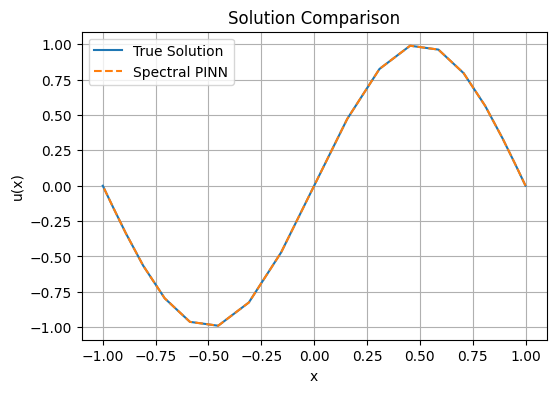

In [97]:
# True solution (depends on your PDE choice)
u_true = torch.sin(torch.pi * x)

# Predicted solution from model
with torch.no_grad():
    c = model_smw()          # use trained model
    u_pred = Phi @ c

# Move to numpy
x_np = x.detach().cpu().numpy()
u_true_np = u_true.detach().cpu().numpy()
u_pred_np = u_pred.detach().cpu().numpy()

# Plot: True vs Predicted
plt.figure(figsize=(6,4))
plt.plot(x_np, u_true_np, label="True Solution")
plt.plot(x_np, u_pred_np, '--', label="Spectral PINN")

plt.legend()
plt.title("Solution Comparison")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.grid()
plt.show()

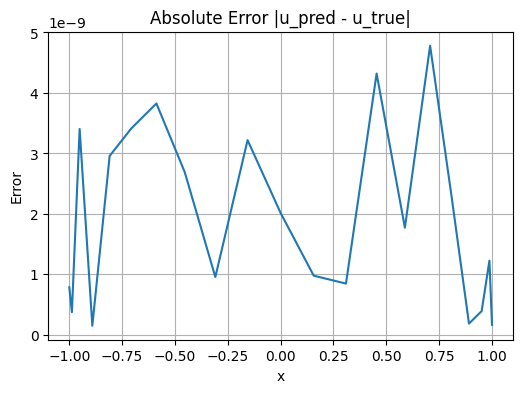

In [98]:
# Absolute error
error = torch.abs(u_pred - u_true)
error_np = error.detach().cpu().numpy()

plt.figure(figsize=(6,4))
plt.plot(x_np, error_np)

plt.title("Absolute Error |u_pred - u_true|")
plt.xlabel("x")
plt.ylabel("Error")
plt.grid()
plt.show()

In [99]:
# Relative L2 error
l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)

print("Relative L2 Error:", l2_error.item())

Relative L2 Error: 3.975243199404032e-09


## refactoring the method 1

In [100]:
def setup_problem(N):
    """
    Build A, Phi, f for given N
    """
    
    K = max(10, min(40, N//3)) # important scaling
    
    # Grid
    x, D = chebyshev_diff_matrix(N)
    
    # Operator
    A = build_A(D, bc_weight=10.0)
    
    # Basis
    Phi = chebyshev_basis(x, K)
    
    # Correct RHS
    f = (torch.pi**2) * torch.sin(torch.pi * x)
    f = torch.cat([f, torch.zeros(2)])
    
    return x, A, Phi, f, K

In [101]:
def build_hodlr(A, x, p=16):
    """
    Build mixed ACA-HODLR operator for rectangular A:
    - ACA-HODLR for square PDE block A[:N+1, :]
    - Dense multiply for BC rows A[N+1:, :]
    
    Note: x and p are kept for compatibility with existing call sites.
    """
    A_np = A.detach().cpu().numpy()

    leaf_size = max(32, 4 * p)

    H = MixedACAHODLR(
        A_np,
        leaf_size=leaf_size,
        aca_variant="pivoted",
        adaptive=True,
        tol=1e-6,
        max_rank=20,
    )

    return H

In [102]:
def train_method_1(model, H, Phi, A, f, steps=800, lam=1e-3):
    
    losses = []
    
    for i in range(steps):
        
        # B
        B = build_B(model)
        
        # Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        # AΦ (HODLR)
        APhi = compute_A_Phi_hodlr(H, Phi)
        
        # G
        G = compute_G_from_APhi(APhi)
        
        # RHS
        g = compute_rhs_hodlr(H, Phi, B, r)
        
        # μ (correct version)
        mu = lam * torch.max(torch.diag(G))
        mu = lam
        
        # SMW solve
        delta_theta = solve_smw(G, B, g, mu)
        
        # Update
        apply_update(model, delta_theta, lr=0.1)
    
    return losses, model

In [103]:
def run_method_1(N, steps=800):
    
    # Setup
    x, A, Phi, f, K = setup_problem(N)
    
    # Model
    model = CoeffNet(K)
    
    # Build HODLR
    t0 = time.time()
    H = build_hodlr(A, x)
    t1 = time.time()
    
    hodlr_time = t1 - t0
    
    # Train
    t2 = time.time()
    losses, model = train_method_1(model, H, Phi, A, f, steps=steps)
    t3 = time.time()
    
    train_time = t3 - t2
    
    # Prediction
    with torch.no_grad():
        c = model()
        u_pred = Phi @ c
        u_true = torch.sin(torch.pi * x)
    
    # Error
    l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)
    
    return {
        "N": N,
        "hodlr_time": hodlr_time,
        "train_time": train_time,
        "total_time": hodlr_time + train_time,
        "l2_error": l2_error.item(),
        "losses": losses
    }

In [104]:
result = run_method_1(20, steps=10)

print(result)

{'N': 20, 'hodlr_time': 9.799003601074219e-05, 'train_time': 0.011281967163085938, 'total_time': 0.01137995719909668, 'l2_error': 0.5941281533311253, 'losses': [1591.008867665035, 1432.6409237512587, 1289.8523311928684, 1161.1468382030855, 1045.170499070369, 940.6954230428233, 846.6068452594693, 761.8918818441383, 685.6326820073208, 616.992941860672]}


# Method 2: LSQR (Matrix-Free Gauss–Newton)

We solve:

    (J^T J + μI) Δθ = -J^T r

by converting to least squares:

    min ||Q Δθ - b||^2

where:

    Q = [J; sqrt(μ) I]

We NEVER form J explicitly.

We only implement:

    y = Qx
    z = Q^T y

using:
    J = A Φ B

This enables matrix-free optimization.

In [105]:
def forward_Q(H, Phi, B, x, mu):
    """
    Compute:
        y = Qx
    
    where:
        Q = [ J ; sqrt(mu) I ]
        J = A Φ B
    
    Inputs:
        x  : (P,)
        B  : (K, P)
        Phi: (N+1, K)
        H  : HODLR (for A)
        mu : scalar
    
    Output:
        y  : (N+3 + P,)
    """
    
    # Step 1: Bx
    Bx = B @ x                  # (K,)
    
    # Step 2: Φ(Bx)
    PhiBx = Phi @ Bx            # (N+1,)
    
    # Step 3: A(Φ(Bx)) using HODLR
    A_PhiBx = hodlr_matvec(H, PhiBx)   # (N+3,)
    
    # Step 4: sqrt(mu) * x
    reg = (mu ** 0.5) * x           # (P,)
    
    # Step 5: concatenate
    y = torch.cat([A_PhiBx, reg])
    
    return y

In [106]:
P = sum(p.numel() for p in model_smw.parameters())
x_test = torch.randn(P)

B = build_B(model_smw)
mu = 1e-3

y = forward_Q(H, Phi, B, x_test, mu)

print(y.shape)

torch.Size([667])


In [107]:
def adjoint_Q(H, Phi, B, y, mu):
    """
    Compute:
        z = Q^T y
    
    where:
        Q^T y = B^T (Φ^T (A^T y1)) + sqrt(mu) y2
    
    Inputs:
        y  : (N+3 + P,)
    
    Output:
        z  : (P,)
    """
    
    Np3 = H.n_rows   # = N+3
    
    # Step 1: split y
    y1 = y[:Np3]     # (N+3,)
    y2 = y[Np3:]     # (P,)
    
    # Step 2: A^T y1 (HODLR)
    At_y1 = hodlr_matvec_transpose(H, y1)   # (N+1,)
    
    # Step 3: Φ^T (A^T y1)
    PhiT_At_y1 = Phi.T @ At_y1              # (K,)
    
    # Step 4: B^T (...)
    term1 = B.T @ PhiT_At_y1                # (P,)
    
    # Step 5: sqrt(mu) * y2
    term2 = (mu ** 0.5) * y2               # (P,)
    
    # Step 6: sum
    z = term1 + term2
    
    return z

In [108]:
y_test = torch.randn(H.n_rows + P)

z = adjoint_Q(H, Phi, B, y_test, mu)

print(z.shape)

torch.Size([644])


In [109]:
x_test = torch.randn(P)
y_test = torch.randn(H.n_rows + P)

lhs = torch.dot(forward_Q(H, Phi, B, x_test, mu), y_test)
rhs = torch.dot(x_test, adjoint_Q(H, Phi, B, y_test, mu))

print("Adjoint error:", abs(lhs - rhs).item())

Adjoint error: 2.9103830456733704e-11


In [110]:
def lsqr_solver(H, Phi, B, r, mu, max_iter=20):
    """
    Solve:
        min ||Q Δθ - b||^2
    
    using LSQR
    
    Inputs:
        r  : residual (N+3,)
        mu : scalar
    
    Output:
        delta_theta : (P,)
    """
    
    # Build RHS vector b = [-r ; 0]
    P = B.shape[1]
    b = torch.cat([-r, torch.zeros(P)])
    
    # Initial guess
    x = torch.zeros(P)
    
    # --- LSQR Initialization ---
    u = b.clone()
    beta = torch.norm(u)
    u = u / beta
    
    v = adjoint_Q(H, Phi, B, u, mu)
    alpha = torch.norm(v)
    v = v / alpha
    
    w = v.clone()
    
    phi_bar = beta
    rho_bar = alpha
    
    # --- Iterations ---
    for i in range(max_iter):
        
        # Step 1: u = Qv - alpha u
        u = forward_Q(H, Phi, B, v, mu) - alpha * u
        beta = torch.norm(u)
        u = u / beta
        
        # Step 2: v = Q^T u - beta v
        v = adjoint_Q(H, Phi, B, u, mu) - beta * v
        alpha = torch.norm(v)
        v = v / alpha
        
        # Step 3: orthogonal transformation
        rho = torch.sqrt(rho_bar**2 + beta**2)
        c = rho_bar / rho
        s = beta / rho
        
        theta = s * alpha
        rho_bar = -c * alpha
        phi = c * phi_bar
        phi_bar = s * phi_bar
        
        # Step 4: update solution
        x = x + (phi / rho) * w
        w = v - (theta / rho) * w
    
    return x

In [111]:
def lsqr_solver(H, Phi, B, r, mu, max_iter=20):
    """
    Solve:
        min ||Q Δθ - b||^2
    
    using LSQR
    
    Inputs:
        r  : residual (N+3,)
        mu : scalar
    
    Output:
        delta_theta : (P,)
    """
    
    # Build RHS vector b = [-r ; 0]
    P = B.shape[1]
    b = torch.cat([-r, torch.zeros(P)])
    
    # Initial guess
    x = torch.zeros(P)
    
    # --- LSQR Initialization ---
    u = b.clone()
    beta = torch.norm(u)
    u = u / beta
    
    v = adjoint_Q(H, Phi, B, u, mu)
    alpha = torch.norm(v)
    v = v / alpha
    
    w = v.clone()
    
    phi_bar = beta
    rho_bar = alpha
    
    # --- Iterations ---
    for i in range(max_iter):
        
        # Step 1: u = Qv - alpha u
        u = forward_Q(H, Phi, B, v, mu) - alpha * u
        beta = torch.norm(u)
        u = u / beta
        
        # Step 2: v = Q^T u - beta v
        v = adjoint_Q(H, Phi, B, u, mu) - beta * v
        alpha = torch.norm(v)
        v = v / alpha
        
        # Step 3: orthogonal transformation
        rho = torch.sqrt(rho_bar**2 + beta**2)
        c = rho_bar / rho
        s = beta / rho
        
        theta = s * alpha
        rho_bar = -c * alpha
        phi = c * phi_bar
        phi_bar = s * phi_bar
        
        # Step 4: update solution
        x = x + (phi / rho) * w
        w = v - (theta / rho) * w
    
    return x

In [112]:
def train_method_2(model, H, Phi, A, f, steps=800, lam=1e-3, lsqr_iters=20):
    
    losses = []
    
    for i in range(steps):
        
        # Step 1: Build B
        B = build_B(model)
        
        # Step 2: Residual
        r, u, c = compute_residual(model, A, Phi, f)
        
        loss = torch.norm(r)
        losses.append(loss.item())
        
        # Step 3: Fixed damping
        mu = lam
        
        # Step 4: Solve using LSQR
        delta_theta = lsqr_solver(H, Phi, B, r, mu, max_iter=lsqr_iters)
        
        # Step 5: Update
        apply_update(model, delta_theta, lr=0.1)
    
    return losses, model

In [113]:
def run_method_2(N, steps=800, lsqr_iters=100):
    
    # Setup
    x, A, Phi, f, K = setup_problem(N)
    
    # Model
    model = CoeffNet(K)
    
    # Build HODLR
    t0 = time.time()
    H = build_hodlr(A, x)
    t1 = time.time()
    
    hodlr_time = t1 - t0
    
    # Train
    t2 = time.time()
    losses, model = train_method_2(
        model, H, Phi, A, f,
        steps=steps,
        lsqr_iters=lsqr_iters
    )
    t3 = time.time()
    
    train_time = t3 - t2
    
    # Prediction
    with torch.no_grad():
        c = model()
        u_pred = Phi @ c
        u_true = torch.sin(torch.pi * x)
    
    # Error
    l2_error = torch.norm(u_pred - u_true) / torch.norm(u_true)
    
    return {
        "N": N,
        "hodlr_time": hodlr_time,
        "train_time": train_time,
        "total_time": hodlr_time + train_time,
        "l2_error": l2_error.item(),
        "losses": losses
    }

In [114]:
result2 = run_method_2(20, steps=10, lsqr_iters=10)

print(result2)

{'N': 20, 'hodlr_time': 0.00012421607971191406, 'train_time': 0.017323017120361328, 'total_time': 0.017447233200073242, 'l2_error': 0.5652056571216137, 'losses': [136.27895425071188, 122.65600313378071, 110.38268454937784, 99.32981546376192, 89.37989315545133, 80.42570579583915, 72.36944501224578, 65.1220715041295, 58.60276744692195, 52.73839557864879]}


In [115]:
N_list_small = [4, 12, 20, 28, 36, 44, 52, 60]

results_m1 = []
results_m2 = []

for N in N_list_small:
    print(f"\nRunning N = {N}")
    
    res1 = run_method_1(N, steps=800)
    res2 = run_method_2(N, steps=800, lsqr_iters=100)
    
    results_m1.append(res1)
    results_m2.append(res2)


Running N = 4

Running N = 12

Running N = 20

Running N = 28

Running N = 36

Running N = 44

Running N = 52

Running N = 60


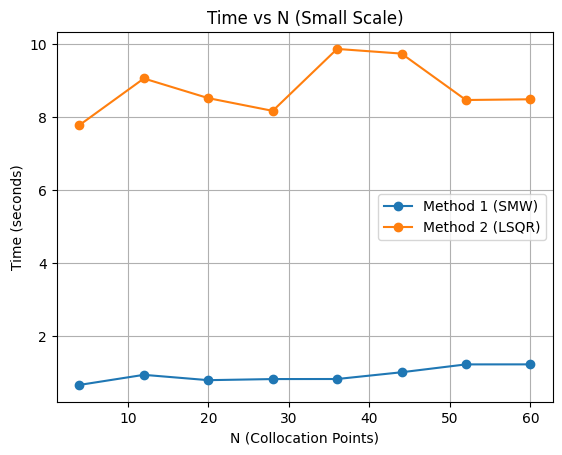

In [116]:
N_vals = [r["N"] for r in results_m1]

time_m1 = [r["total_time"] for r in results_m1]
time_m2 = [r["total_time"] for r in results_m2]

plt.figure()
plt.plot(N_vals, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N_vals, time_m2, 'o-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Small Scale)")
plt.legend()
plt.grid()
plt.show()

In [117]:
N_list_large = [100, 300, 500]

results_m1_large = []
results_m2_large = []

for N in N_list_large:
    print(f"\nRunning N = {N}")
    
    res1 = run_method_1(N, steps=800)
    res2 = run_method_2(N, steps=800, lsqr_iters=100)
    
    results_m1_large.append(res1)
    results_m2_large.append(res2)


Running N = 100

Running N = 300

Running N = 500


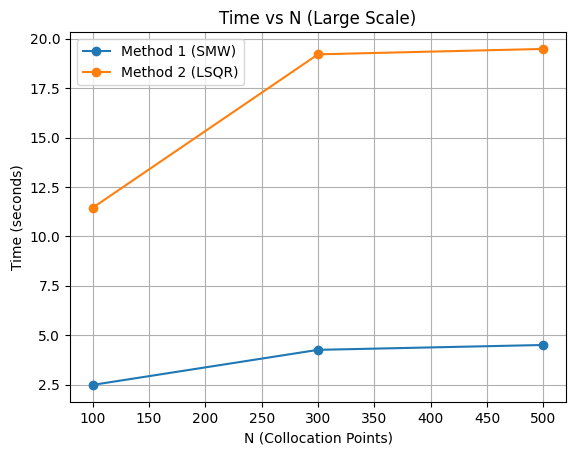

In [118]:
N_vals = [r["N"] for r in results_m1_large]

time_m1 = [r["total_time"] for r in results_m1_large]
time_m2 = [r["total_time"] for r in results_m2_large]

plt.figure()
plt.plot(N_vals, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N_vals, time_m2, 'o-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Large Scale)")
plt.legend()
plt.grid()
plt.show()

In [119]:
def extract_metrics(results):
    N_vals = [r["N"] for r in results]
    times = [r["total_time"] for r in results]
    errors = [r["l2_error"] for r in results]
    
    return N_vals, times, errors

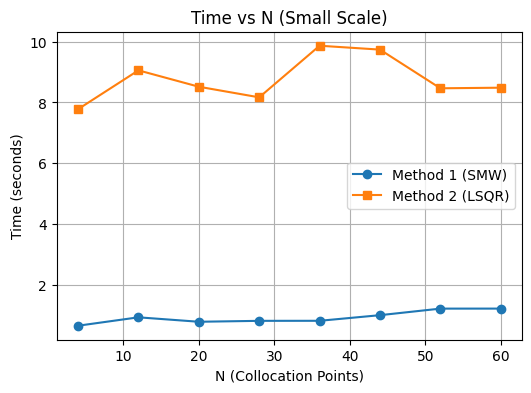

In [120]:
N1, time_m1, err_m1 = extract_metrics(results_m1)
N2, time_m2, err_m2 = extract_metrics(results_m2)

plt.figure(figsize=(6,4))

plt.plot(N1, time_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N2, time_m2, 's-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Small Scale)")
plt.legend()
plt.grid()
plt.show()

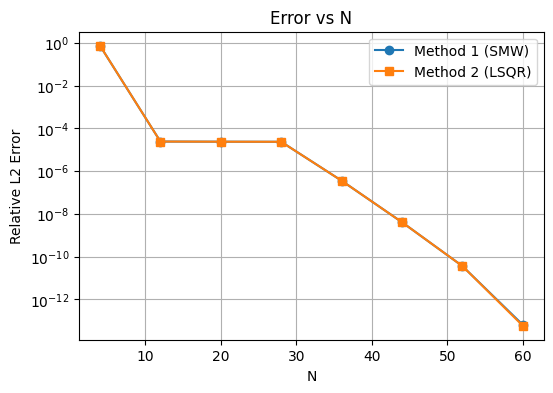

In [121]:
plt.figure(figsize=(6,4))

plt.plot(N1, err_m1, 'o-', label="Method 1 (SMW)")
plt.plot(N2, err_m2, 's-', label="Method 2 (LSQR)")

plt.yscale('log')

plt.xlabel("N")
plt.ylabel("Relative L2 Error")
plt.title("Error vs N")
plt.legend()
plt.grid()
plt.show()

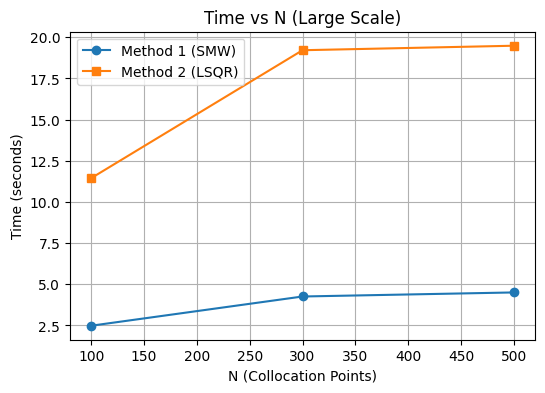

In [122]:
N1L, time_m1L, err_m1L = extract_metrics(results_m1_large)
N2L, time_m2L, err_m2L = extract_metrics(results_m2_large)

plt.figure(figsize=(6,4))

plt.plot(N1L, time_m1L, 'o-', label="Method 1 (SMW)")
plt.plot(N2L, time_m2L, 's-', label="Method 2 (LSQR)")

plt.xlabel("N (Collocation Points)")
plt.ylabel("Time (seconds)")
plt.title("Time vs N (Large Scale)")
plt.legend()
plt.grid()
plt.show()

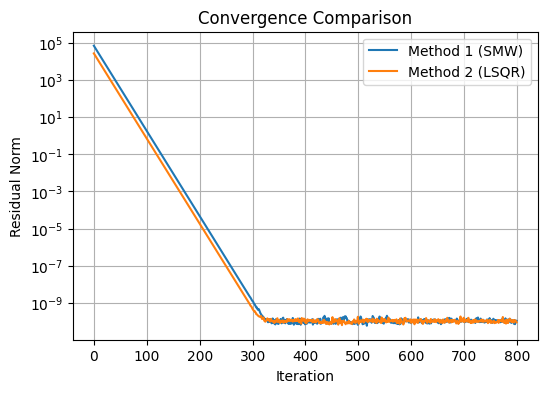

In [123]:
plt.figure(figsize=(6,4))

# pick one N (e.g., last run)
plt.plot(results_m1[-1]["losses"], label="Method 1 (SMW)")
plt.plot(results_m2[-1]["losses"], label="Method 2 (LSQR)")

plt.yscale('log')

plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.title("Convergence Comparison")
plt.legend()
plt.grid()
plt.show()